# FedAvg vs FedVARP

In [83]:
from plots_utils.loading import ExperimentConfig, load_experiment_results
from plots_utils.plot_availability_comparison import plot_availability_comparison
from plots_utils.plot_biased_unbiased_comparison import plot_biased_unbiased_comparison
from plots_utils.plot_av_mat import plot_av_mat
from plots_utils.quanti import refine_results, plot_mean_seeds_var_over_training, plot_final_best_test_acc, plot_final_best_worst_test_acc
from matplotlib import pyplot as plt
import os
import seaborn as sns
import pandas as pd
import numpy as np
folder='figures/alphaF_exp'
keyword = 'alphaF_exp'
main_folder = 'correlation_experiments_100rounds'

def fct_refine_res(res):
    res = res[["dataseed", "availability", "test_accuracy", "seed", "lr"]]

    # only look at the final accuracy:
    res.loc[:,['final_acc']] = res['test_accuracy'].apply(lambda x : x[-1])

    # take the best value accross learning rates:
    refined_res = res.groupby(['availability','dataseed', 'seed']).final_acc.apply(np.vstack).to_frame().reset_index()
    refined_res['final_best_acc'] = refined_res['final_acc'].apply(lambda x : x.max())

    refined_res = refined_res[['availability', 'final_best_acc', 'dataseed', 'seed']]

    # regroup all seeds results:
    refined_res = refined_res.groupby(['availability']).final_best_acc.apply(np.vstack).to_frame().reset_index() # regroup seeds results

    # compute the mean and std/3:
    refined_res['mean_acc'] = refined_res['final_best_acc'].apply(lambda x : x.mean())
    refined_res['std_3_acc'] = refined_res['final_best_acc'].apply(lambda x : x.std()/3)

    return(refined_res)

# Comparing Fine-tuning without fine-tuning

Processing experiments:   0%|          | 0/1 [00:00<?, ?it/s]

Processing experiments: 100%|██████████| 1/1 [00:00<00:00,  1.17it/s]


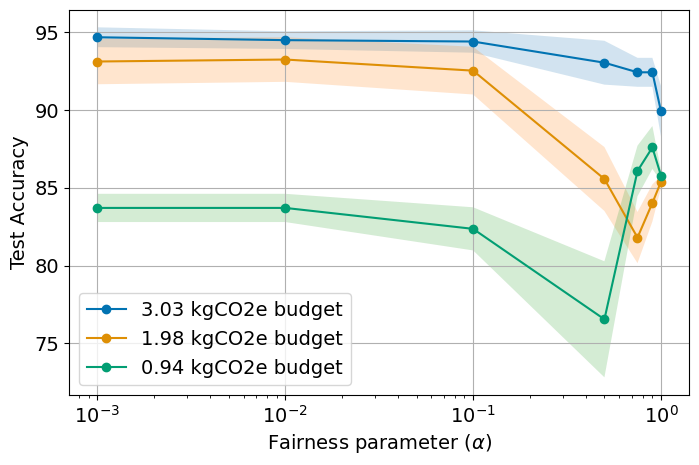

In [84]:
seeds=["42", "78", "84"]

cb_list = ["7cb", "8cb", "10cb"]
lrs_list = [["5e-2"], ["5e-2", "1e-2"], ["5e-2"]]
lab_list = ["3.03 kgCO2e", "1.98 kgCO2e", "0.94 kgCO2e"]

plt.figure(figsize=(8, 5))
ax=plt.gca()

for i in range(len(cb_list)):

    cb = cb_list[i]
    lrs = lrs_list[i]
    lab = lab_list[i]
    availabilities = f"alphaF50-alpha0.001-{cb} alphaF50-alpha0.01-{cb} alphaF50-alpha0.1-{cb} alphaF50-alpha0.5-{cb} alphaF50-alpha0.75-{cb} alphaF50-alpha0.9-{cb} alphaF50-alpha1.0-{cb}".split()

    final_results = pd.DataFrame()

    for ds_idx, ds in enumerate(["12345", "12346", "12347"]):

        config = ExperimentConfig(
            base_path=os.path.join("..", "logs"),
            experiment="mnist_alphaF_var/dataseed_"+ds,
            seeds=seeds,
            algorithms=["fedavg"],
            events=["global"],
            lr_list=lrs,
            alphas=["0.1"],
            n_clients_list=["7"],
            availabilities=availabilities,
            n_rounds="50",
            participations=["known"],
            biased_list=["2"],
            train_test="train",
        )

        raw_results = load_experiment_results(config)
        raw_results['dataseed'] = ds
        final_results = pd.concat([final_results, raw_results])

    refined_res = fct_refine_res(final_results)
    x_values = [float(a.replace('alphaF50-alpha','').replace(f"-{cb}", '')) for a in refined_res['availability']]
    y = refined_res['mean_acc'] *100
    y_upper = (refined_res['mean_acc']+ refined_res['std_3_acc']) *100
    y_lower =  (refined_res['mean_acc']- refined_res['std_3_acc']) *100
    colorblind_palette = sns.color_palette("colorblind")
    plt.plot(x_values, y, '-o', label = lab+" budget", color=colorblind_palette[i % len(colorblind_palette)])
    plt.xticks(fontsize=14)  # rotate x-axis labels to diagonal
    plt.yticks(fontsize=14)  # rotate x-axis labels to diagonal
    ax.fill_between(x_values, y_upper, y_lower, alpha=0.2)

plt.xscale('log')
plt.legend(fontsize=14)
# plt.title('Final Mean Test Accuracy with Variance Band - 8cb')
plt.grid()
# ax.set_ylim([86, 100])
plt.xlabel("Fairness parameter ($\\alpha$)", fontsize=14)
plt.ylabel("Test Accuracy", fontsize=14)
plt.savefig(folder+f"/alphaF_var-allcb.png", bbox_inches='tight')

In [85]:
# cb = "10cb"
# lrs=["5e-2", "1e-2"]

# cb = "7cb"
# lrs=["5e-2"]

# plt.figure()
# ax=plt.gca()

# seeds=["42", "78", "84"]
# availabilities = f"alphaF50-alpha0.001-{cb} alphaF50-alpha0.01-{cb} alphaF50-alpha0.1-{cb} alphaF50-alpha0.5-{cb} alphaF50-alpha0.75-{cb} alphaF50-alpha0.9-{cb} alphaF50-alpha1.0-{cb}".split()

# colorblind_palette = sns.color_palette("colorblind")

# final_results = pd.DataFrame()

# for ds_idx, ds in enumerate(["12345", "12346", "12347"]):
# # for ds_idx, ds in enumerate(["12346", "12347"]):

#     config = ExperimentConfig(
#         base_path=os.path.join("..", "logs"),
#         experiment="mnist_alphaF_var/dataseed_"+ds,
#         seeds=seeds,
#         algorithms=["fedavg"],
#         events=["global"],
#         lr_list=lrs,
#         alphas=["0.1"],
#         n_clients_list=["7"],
#         availabilities=availabilities,
#         n_rounds="50",
#         participations=["known"],
#         biased_list=["2"],
#         train_test="train",
#     )

#     raw_results = load_experiment_results(config)
#     raw_results['algorithm'] = ds

#     final_results = pd.concat([final_results, raw_results])

#     # raw_results["availability"] = raw_results["availability"].str.replace(r"-2$", "", regex=True)
    

# refined_res, best_worst_res = refine_results(final_results)

# for ds_idx, ds in enumerate(["12345", "12346", "12347"]):

#     x_values = [a.replace('alphaF50-alpha','').replace(f"-{cb}", '') for a in best_worst_res[best_worst_res.algorithm==ds]['availability']]
#     y = best_worst_res[best_worst_res.algorithm==ds]['best_final_mean_acc'] *100
#     y_upper = best_worst_res[best_worst_res.algorithm==ds]['best_final_max_acc'] *100
#     y_lower = best_worst_res[best_worst_res.algorithm==ds]['best_final_min_acc'] * 100
#     plt.plot(x_values, y, '-o', label="data seed "+str(ds_idx), color=colorblind_palette[ds_idx % len(colorblind_palette)])
#     plt.xticks(fontsize=14)  # rotate x-axis labels to diagonal
#     plt.yticks(fontsize=14)  # rotate x-axis labels to diagonal
#     ax.fill_between(x_values, y_upper, y_lower, alpha=0.2)


# plt.legend(fontsize=14)
# # plt.title('Final Mean Test Accuracy with Variance Band - 8cb')
# plt.grid()
# # ax.set_ylim([86, 100])
# plt.xlabel("alpha", fontsize=14)
# plt.ylabel("Test Accuracy", fontsize=14)
# plt.savefig(folder+f"/alphaF_var-{cb}.png", bbox_inches='tight')

## Av mat

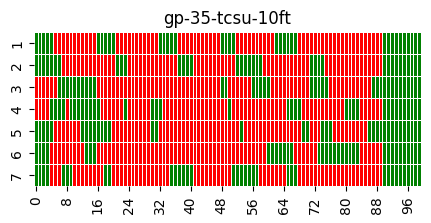

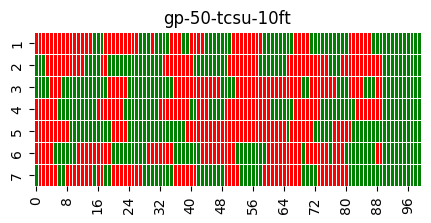

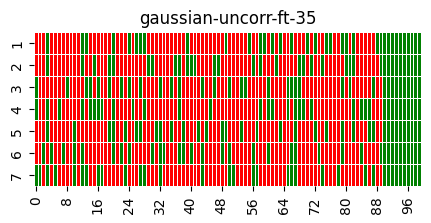

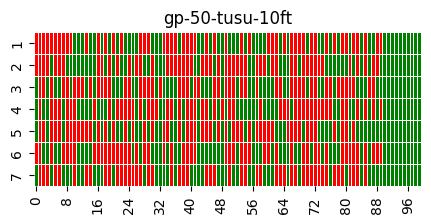

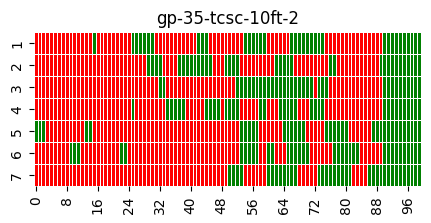

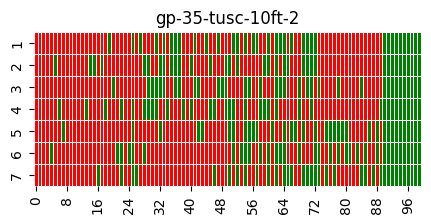

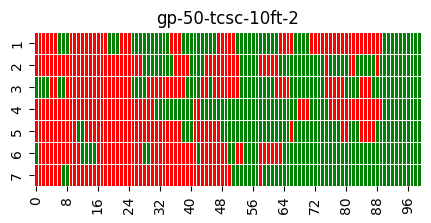

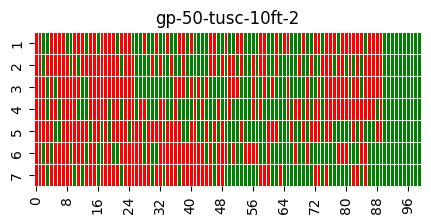

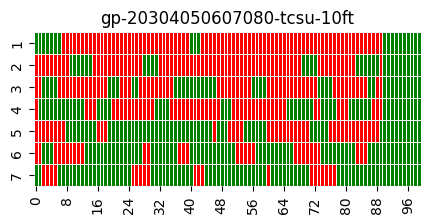

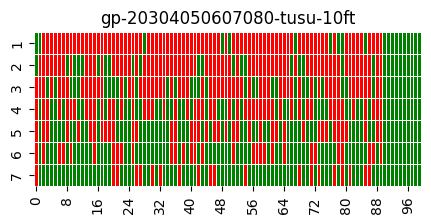

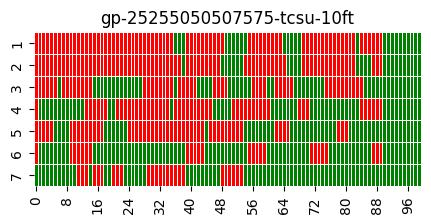

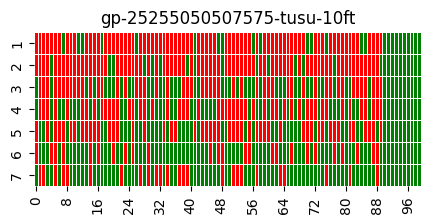

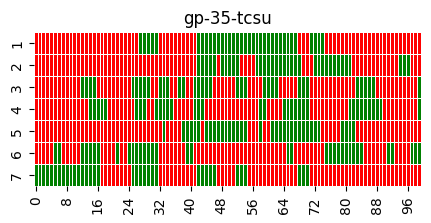

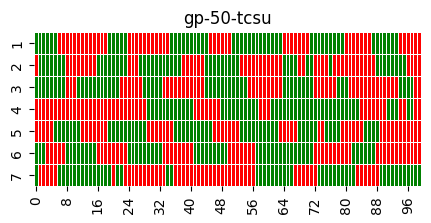

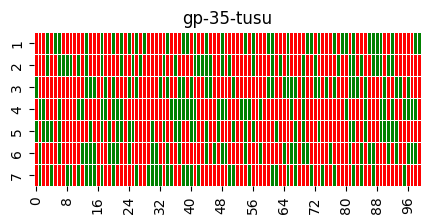

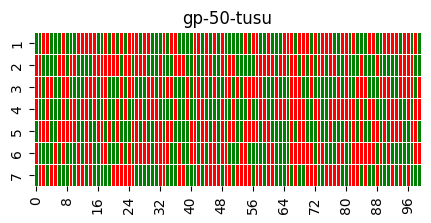

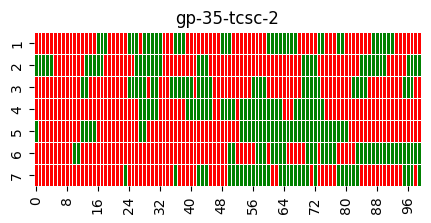

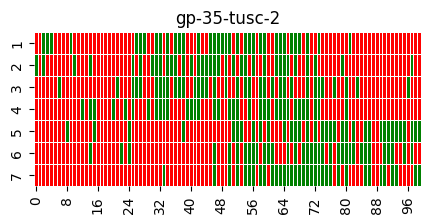

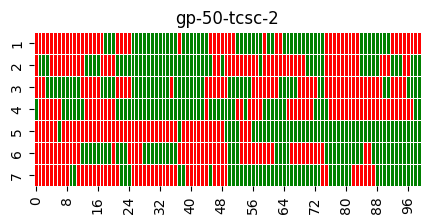

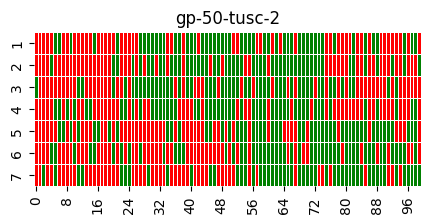

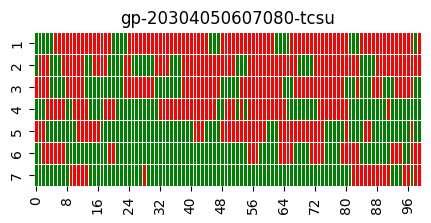

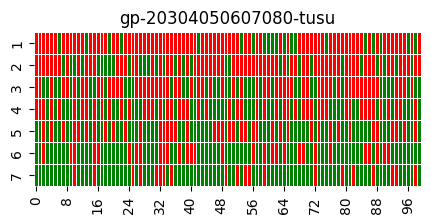

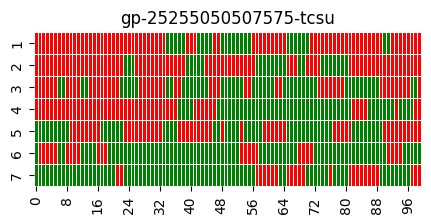

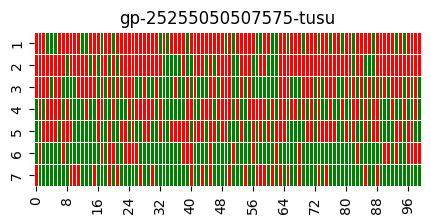

In [86]:
av_mat_list = ['gp-35-tcsu-10ft',
 'gp-50-tcsu-10ft',
#  'gp-35-tusu-10ft',
 'gaussian-uncorr-ft-35',
 'gp-50-tusu-10ft',
 'gp-35-tcsc-10ft-2',
 'gp-35-tusc-10ft-2',
 'gp-50-tcsc-10ft-2',
 'gp-50-tusc-10ft-2',
 'gp-20304050607080-tcsu-10ft',
 'gp-20304050607080-tusu-10ft',
 'gp-25255050507575-tcsu-10ft',
 'gp-25255050507575-tusu-10ft',
 'gp-35-tcsu',
 'gp-50-tcsu',
 'gp-35-tusu',
 'gp-50-tusu',
 'gp-35-tcsc-2',
 'gp-35-tusc-2',
 'gp-50-tcsc-2',
 'gp-50-tusc-2',
 'gp-20304050607080-tcsu',
 'gp-20304050607080-tusu',
 'gp-25255050507575-tcsu',
 'gp-25255050507575-tusu']
folder='lr_exp/av_mat'
for av_mat_name in av_mat_list:
    plot_av_mat(av_mat_name, folder)